# Power diagnostics notebook

## Load packages and define functions

In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

<IPython.core.display.Javascript object>

In [2]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [3]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')
REMIND_RMAP

RegionMapping(model_name='REMIND_2.1', iso_to_region=ISO
ABW    LAM
AFG    OAS
AGO    SSA
AIA    LAM
ALA    EUR
      ... 
WSM    OAS
YEM    MEA
ZAF    SSA
ZMB    SSA
ZWE    SSA
Name: REMIND_2.1.REGION, Length: 246, dtype: object, region_names={'LAM': 'Latin America and the Caribbean', 'OAS': 'Other Asia', 'SSA': 'Sub-Saharan Africa', 'EUR': 'EU28', 'NEU': 'Europe (non-EU28)', 'MEA': 'Middle East and North Africa', 'REF': 'Russia', 'CAZ': 'Canada, Australia and New Zealand', 'CHA': 'China', 'IND': 'India', 'JPN': 'Japan', 'USA': 'USA'})

## Define config

In [4]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",#"EU27",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

IKEA_ISOS.sort()

In [58]:
dscale_project = 'REMIND_Q1_2026'
dscale_suffix = '09_03_2026'

## Load data

In [6]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [7]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [8]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [9]:
NPE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Country assessment"

)

NPE_PATH: os.PathLike = BOX_MOUNT_PATH / NPE_PATH

Load up the input data which is both harmonised and unharmonised REMIND data

In [10]:
input_data = pyam.IamDataFrame(
    f'../input_data/{dscale_project}/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv')

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.core - INFO: Reading file ../input_data/REMIND_Q1_2026/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv


Load up historical data

In [11]:
hist_data_iea = pyam.IamDataFrame('../input_data/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file ../input_data/input_reference_iea_2022.csv


Load up SIAMESE data for comparison with old results

In [12]:
npe_siamese = pyam.IamDataFrame(NPE_PATH / '3_Data/results_v12/siamese.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Country assessment/3_Data/results_v12/siamese.csv


Load up DSCALE results

In [59]:
dscale_results = pyam.IamDataFrame(f'../results/5_Explorer_and_New_Variables/{dscale_project}/{dscale_suffix}/REMIND 3.4_2023_harmo_step5h_hydrogen.csv')

pyam.core - INFO: Reading file ../results/5_Explorer_and_New_Variables/REMIND_Q1_2026/09_03_2026/REMIND 3.4_2023_harmo_step5h_hydrogen.csv


In [15]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [16]:
dscale_results_agg = pyam.IamDataFrame(create_macro_df(dscale_results).timeseries())

## Power sector plotting

In [28]:
power_mix_var = [
'Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Coal',
 'Secondary Energy|Electricity|Gas',
 'Secondary Energy|Electricity|Geothermal',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Wind', 
#  'Secondary Energy|Electricity|Non-Biomass Renewables'
 ]


In [29]:
power_color_map = {
    'Secondary Energy|Electricity|Biomass': "#4ed670",
    'Secondary Energy|Electricity|Coal': '#4d4d4d',
    'Secondary Energy|Electricity|Gas': "#908E8E",
    'Secondary Energy|Electricity|Geothermal': "#F02727",
    'Secondary Energy|Electricity|Hydro': "#5fa2cf",
    'Secondary Energy|Electricity|Nuclear': '#e78ac3',
    'Secondary Energy|Electricity|Oil': "#9F9F9F",
    'Secondary Energy|Electricity|Solar': '#ffd92f',
    'Secondary Energy|Electricity|Wind': '#1f78b4',
    'Secondary Energy|Electricity|Non-Biomass Renewables': '#ffd92f'
}

power_legend_key = []
for color in power_color_map.keys():
    power_legend_key.append(mpatches.Patch(label=color,color=power_color_map[color]))


hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

pyam.run_control().update({"color": {"variable": power_color_map}, "hatch" : {"scenario" : hatch}})

### Consistency checks

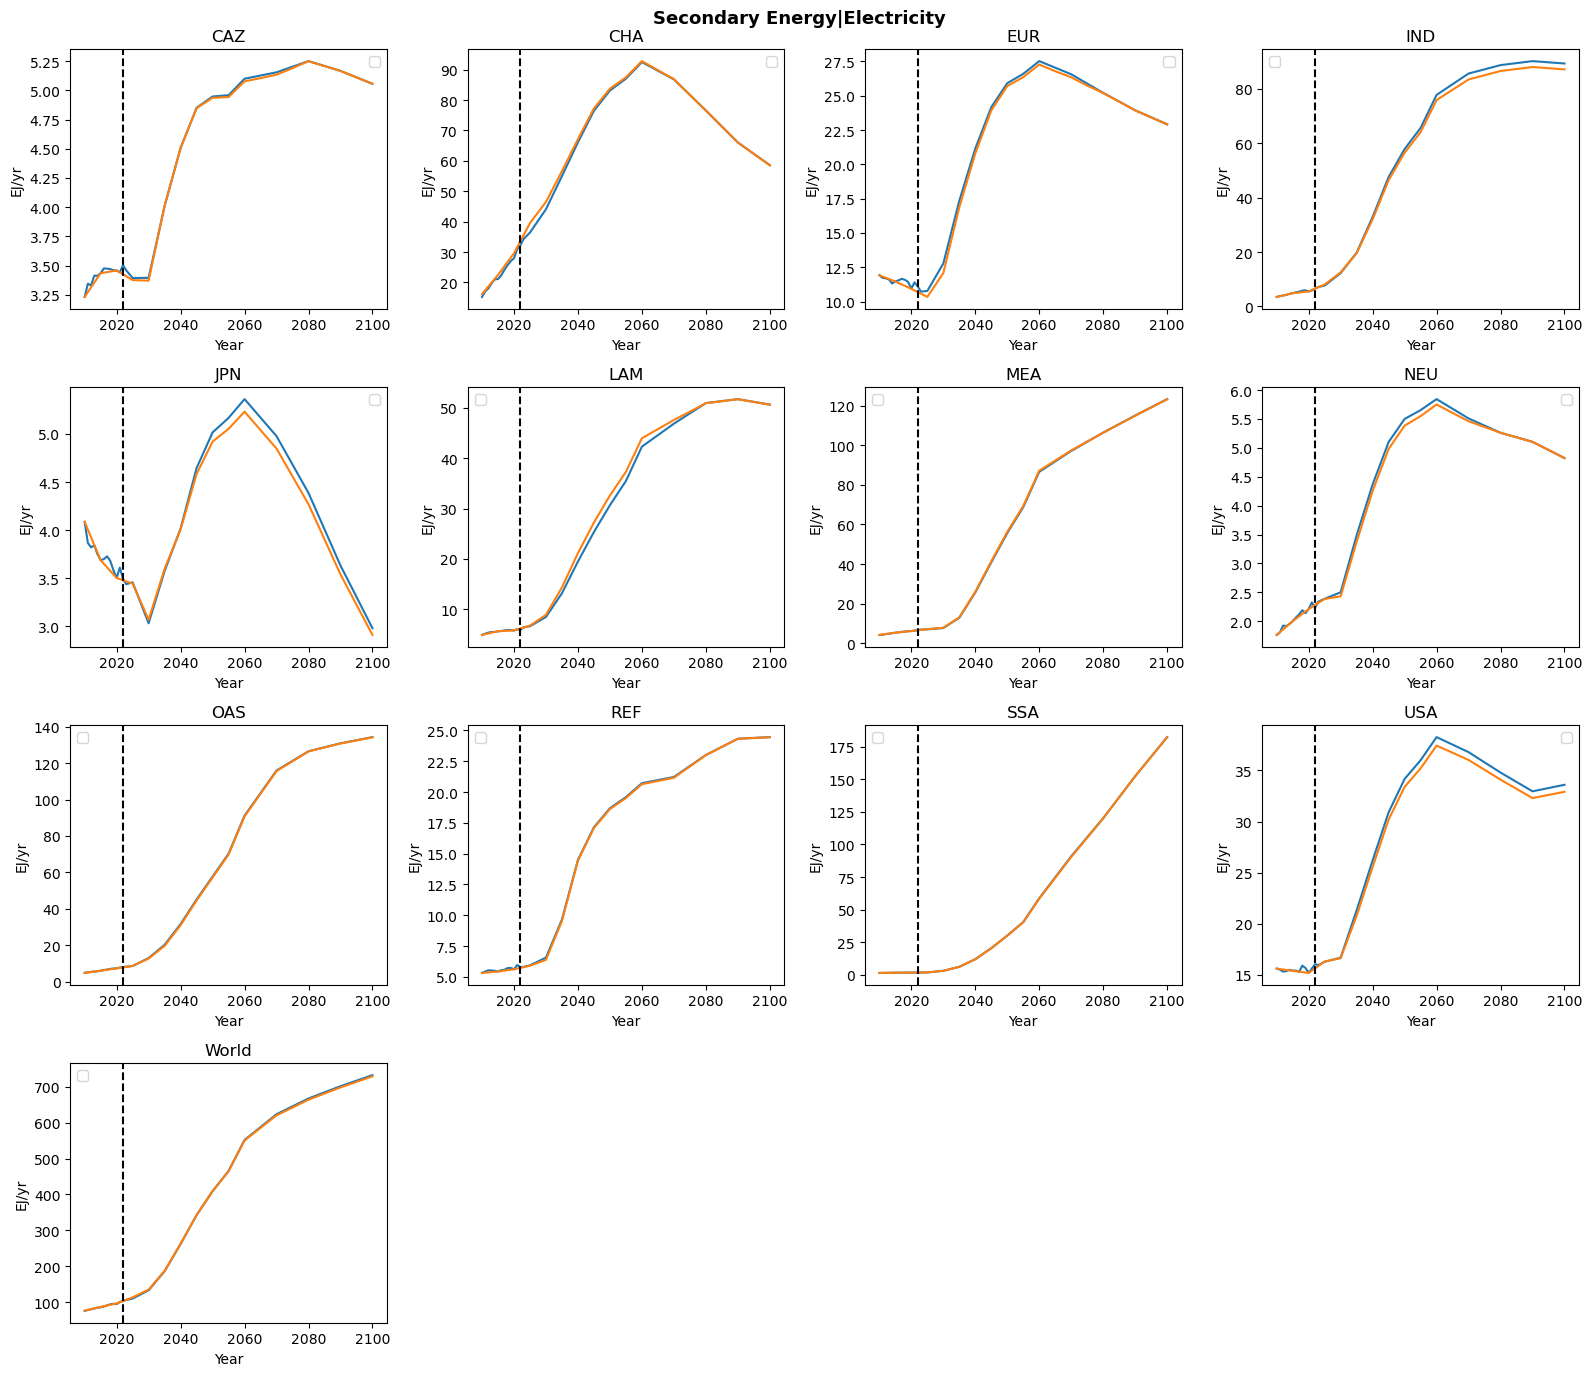

In [30]:
regions = sorted(dscale_results_agg.region)
plot_var = elec()
ncols = 4
nrows = (len(regions) + ncols - 1) // ncols

f, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 3.5))
shared_handles = None

for ax, plot_reg in zip(axes.ravel(), regions):
    input_data.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    dscale_results_agg.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    ax.axvline(x=2022, color='k', ls='--')
    ax.set_title(plot_reg)
    if shared_handles is None:
        shared_handles, _ = ax.get_legend_handles_labels()
    ax.legend([])

for ax in axes.ravel()[len(regions):]:
    ax.set_visible(False)

f.suptitle(plot_var, fontsize=13, fontweight='bold')
if shared_handles:
    f.legend(
        shared_handles,
        ['Input data', 'Re-aggregated downscaling'][:len(shared_handles)],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.01),
    )
plt.tight_layout()

### Electricity mix diagnostics

In [70]:
for fuel in power_mix_var[:-1]:
    f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
    fuel_short = fuel.lstrip("Secondary Energy|Electricity|")
    if fuel_short == '':
        fuel_short = 'Solar'

    for count, ax in enumerate(axes.ravel()[:]):
        dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=fuel,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
        hist_data_iea.filter(region=IKEA_ISOS[count],variable=fuel,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
        ax.axvline(x=2020,color='k',ls='--')
        ax.axhline(y=0,color='k',ls='-')
        ax.set_title(IKEA_ISOS[count])
        ax.legend([])


    f.suptitle(f'{fuel_short} power sector transition',fontsize=14,fontweight='bold', y=1)
    f.legend(['DSCALE results','Historical data'],ncols=2)
    plt.tight_layout()
    Path(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/power_diagnostics').mkdir(parents=True,exist_ok=True)
    plt.savefig(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/power_diagnostics/{fuel_short}.png',dpi=300)
    plt.close()


pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


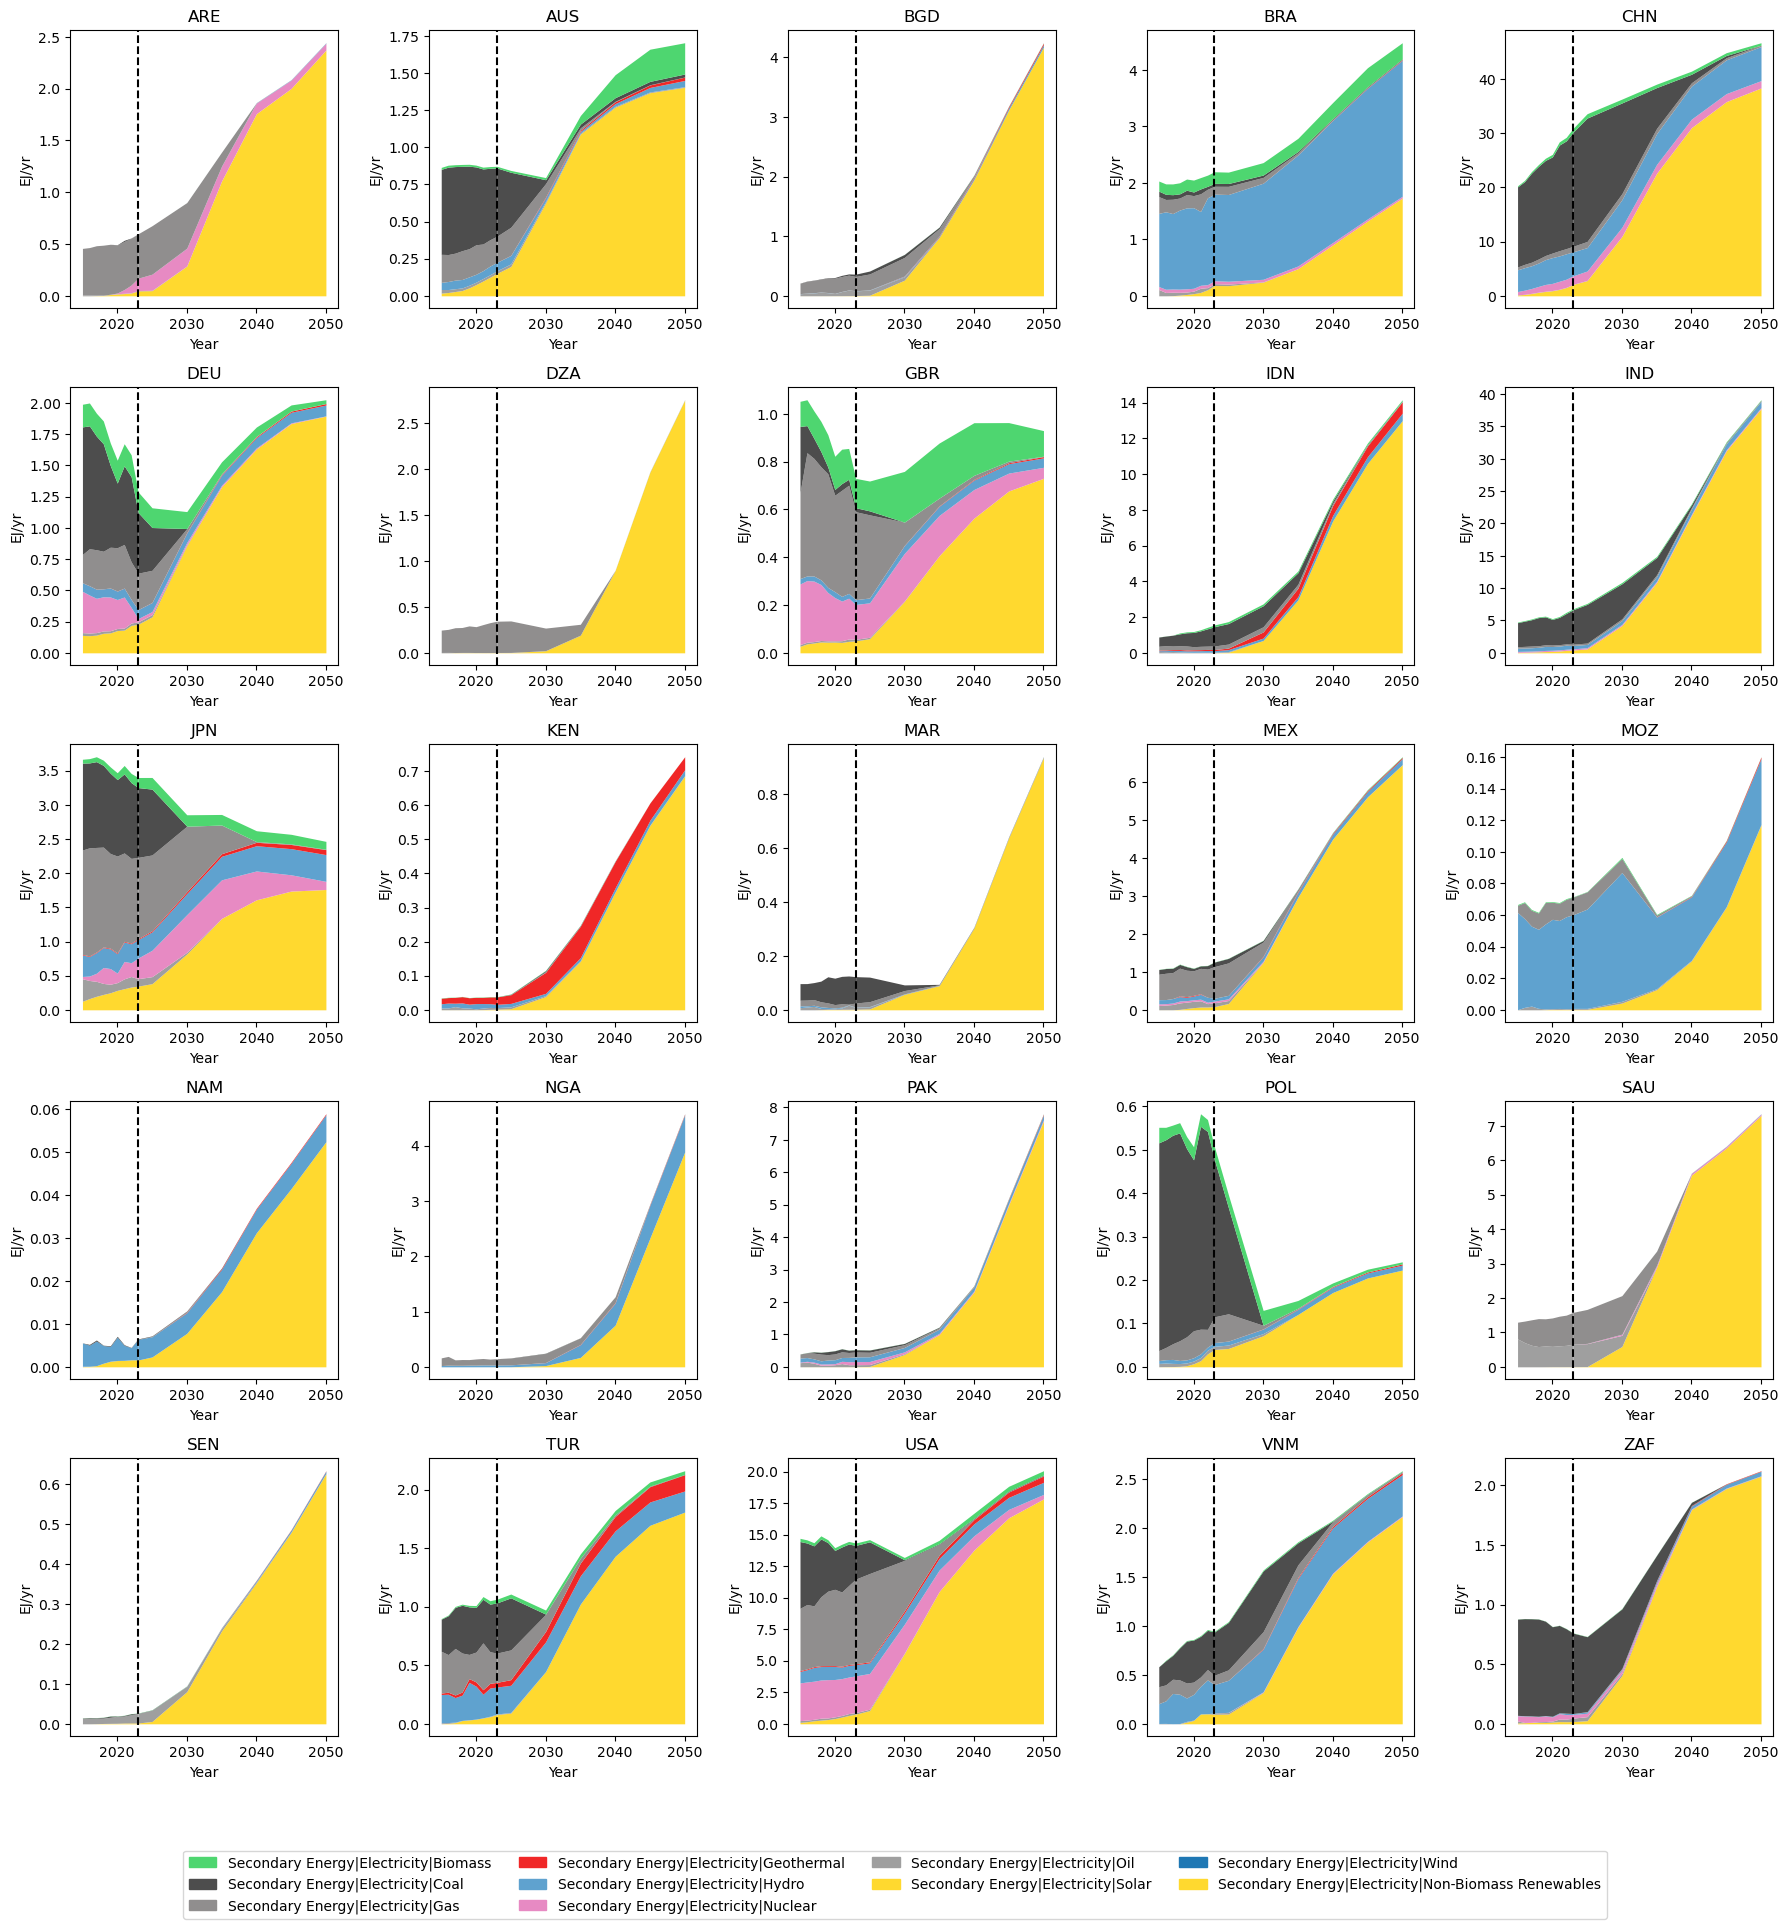

In [60]:
year_proj = [
2023,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100]
]
f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    try:
        dscale_results.filter(
            scenario='NPE-core',
            region=IKEA_ISOS[count],
            variable=power_mix_var[:-1],
            year = year_proj
        ).plot.stack(ax=ax,)
    except:
        print(f'Error plotting results for {IKEA_ISOS[count]}')

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=power_mix_var[:-1],
        year=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    ).plot.stack(ax=ax)

    ax.axvline(x=2023, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

# f.suptitle('Power sector mix',fontsize=14,fontweight='bold')
f.legend(power_legend_key,[l.get_label() for l in power_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()
Path(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/power_diagnostics').mkdir(parents=True,exist_ok=True)
plt.savefig(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/power_diagnostics/fuel_mix.png',dpi=300)
      

### Comparison with NPE Siamese

In [32]:
from matplotlib.patches import Patch

tech_handles = [
    Patch(
        facecolor=power_color_map[v],
        edgecolor="k",
        label=v.split('|')[-1]
    )
    for v in power_mix_var
]

scenario_handles = [
    Patch(
        facecolor="white",
        edgecolor="k",
        hatch="",
        label="NPE-core"
    ),
    Patch(
        facecolor="white",
        edgecolor="k",
        hatch="//",
        label="Deep"
    )
]


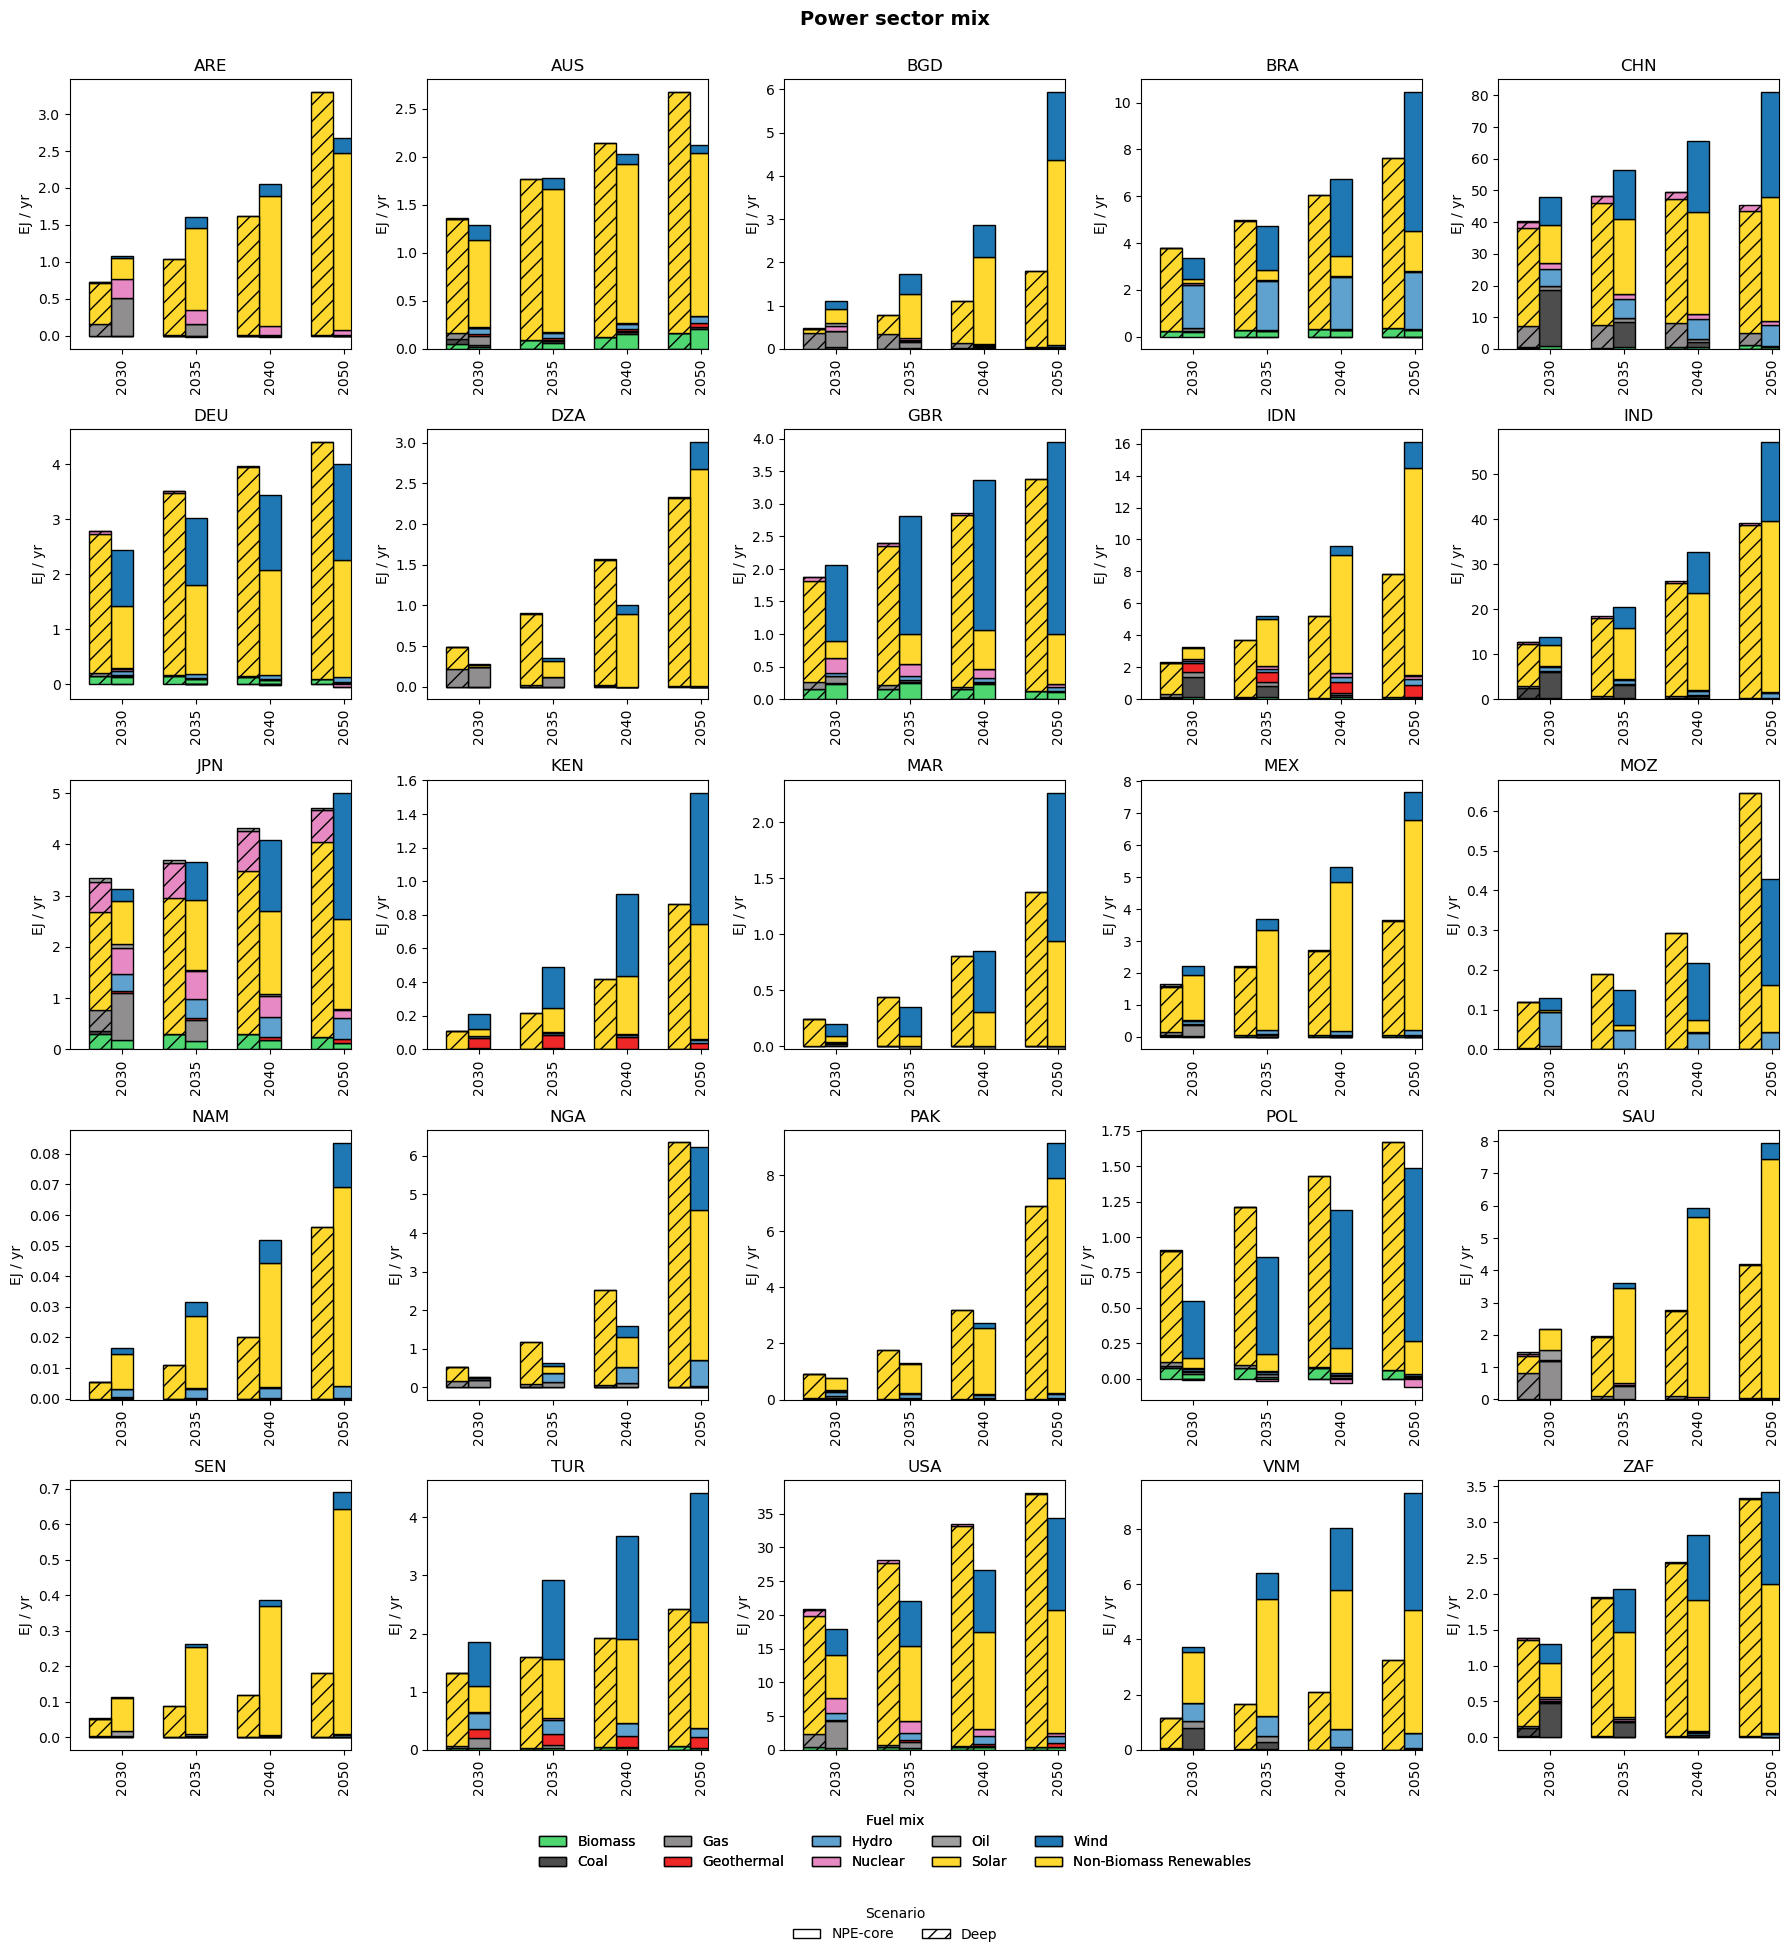

In [33]:


f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        year = [2030,2035,2040,2050],
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=power_mix_var[:-1]
    ).plot.bar(stacked=True, ax=ax, width=0.3, edgecolor="k")

    npe_siamese.filter(
        year = [2030,2035,2040,2050], 
        variable = power_mix_var, 
        region = IKEA_ISOS[count], 
        scenario = "*Deep*"
    ).plot.bar(stacked=True, ax = ax, position=1.5, width=0.3, hatch="//", edgecolor="k")

    # ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.set_xlabel("")
    ax.legend().remove()
    # ax.set_xlim(2020,2060)

# LEGEND
# Technology legend
leg1 = f.legend(
    handles=tech_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
    title="Fuel mix"
)

# Scenario legend
leg2 = f.legend(
    handles=scenario_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    title="Scenario"
)

# Ensure both legends stay visible
f.add_artist(leg1)


f.suptitle('Power sector mix',fontsize=14,fontweight='bold', y =1)
# f.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

# f.legend()
plt.tight_layout()

In [34]:
# Compute shares
for var in power_mix_var:
    dscale_results.divide(
        var, 
        'Secondary Energy|Electricity', 
        var+"|share", 
        ignore_units= "%",
        append=True, 
    )


## Phase out year

In [ ]:
def phaseout_metric(x, threshold):
    x_values = x[x < threshold]
    return x_values.index[0] if len(x_values) > 0 else "Post-2050"

#Get yearly data
def yearly_data(df):
    df_copy = df.copy()
    df = pd.DataFrame(columns=range(2019,2071,1))
    for i in range(len(df_copy.columns)):
        df[df_copy.columns[i]] = df_copy[df_copy.columns[i]]
    
    df = df.astype("float").interpolate(method="linear",axis=1)
        
    return df

#Phaseout date based on when electricity share is <2.5% total electricity
df_electricity_share = yearly_data(dscale_results.filter(variable = "*share").timeseries())

phaseout_electricity_share = df_electricity_share.loc[isin(variable=["Secondary Energy|Electricity|Coal|share",
                                                            "Secondary Energy|Electricity|Gas|share"],region=IKEA_ISOS)].apply(
        lambda x: phaseout_metric(x, 0.025),
        axis = 1
    ).sort_index(level="variable")

In [ ]:
pd.DataFrame(phaseout_electricity_share).unstack("variable")

0  \
variable                        Secondary Energy|Electricity|Coal|share   
model      scenario region unit                                           
REMIND 3.4 NPE-core ARE    %                                       2024   
                    AUS    %                                       2030   
                    BGD    %                                       2035   
                    BRA    %                                       2023   
                    CHN    %                                       2040   
                    DEU    %                                       2030   
                    DZA    %                                       2021   
                    GBR    %                                       2026   
                    IDN    %                                       2043   
                    IND    %                                       2040   
                    JPN    %                                       2030   
                    KEN    %                                       2020   
                    MAR    %                                       2035   
                    MEX    %                                       2030   
                    MOZ    %                                       2020   
                    NAM    %                                       2021   
                    NGA    %                                       2035   
                    PAK    %                                       2036   
                    POL    %                                       2030   
                    SAU    %                                       2020   
                    SEN    %                                       2020   
                    TUR    %                                       2030   
                    USA    %                                       2030   
                    VNM    %                                       2037   
                    ZAF    %                                       2039   

                                                                        
variable                        Secondary Energy|Electricity|Gas|share  
model      scenario region unit                                         
REMIND 3.4 NPE-core ARE    %                                      2038  
                    AUS    %                                      2034  
                    BGD    %                                      2040  
                    BRA    %                                      2032  
                    CHN    %                                      2029  
                    DEU    %                                      2030  
                    DZA    %                                      2040  
                    GBR    %                                      2034  
                    IDN    %                                      2045  
                    IND    %                                      2024  
                    JPN    %                                      2039  
                    KEN    %                                      2020  
                    MAR    %                                      2026  
                    MEX    %                                      2035  
                    MOZ    %                                      2034  
                    NAM    %                                      2020  
                    NGA    %                                      2043  
                    PAK    %                                      2038  
                    POL    %                                      2029  
                    SAU    %                                      2039  
                    SEN    %                                      2020  
                    TUR    %                                      2034  
                    USA    %                                      2037  
                    VNM    %                                      2035 

## Primary energy diagnostics

In [20]:
primary_mix_var = [
    'Primary Energy|Biomass',
    'Primary Energy|Coal',
    'Primary Energy|Gas',
    'Primary Energy|Geothermal',
    'Primary Energy|Hydro',
    'Primary Energy|Nuclear',
    'Primary Energy|Oil',
    'Primary Energy|Solar',
    'Primary Energy|Wind',
    # 'Primary Energy|Non-Biomass Renewables'
]

In [21]:
color_map = {
    'Primary Energy|Biomass': "#4ed670",
    'Primary Energy|Coal': '#4d4d4d',
    'Primary Energy|Gas': "#908E8E",
    'Primary Energy|Geothermal': "#F02727",
    'Primary Energy|Hydro': "#5fa2cf",
    'Primary Energy|Nuclear': '#e78ac3',
    'Primary Energy|Oil': "#9F9F9F",
    'Primary Energy|Solar': '#ffd92f',
    'Primary Energy|Wind': '#1f78b4',
    # 'Primary Energy|Non-Biomass Renewables': '#ffd92f'
}

legend_key = []
for color in color_map.keys():
    legend_key.append(mpatches.Patch(label=color,color=color_map[color]))


hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

linestyle = {
    'Secondary Energy|Electricity|Gas' : '--'
}

pyam.run_control().update({"color": {"variable": color_map}, "hatch" : {"scenario" : hatch}})

In [38]:
for fuel in primary_mix_var[:]:
    f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
    fuel_short = fuel.lstrip("Primary Energy|")
    if fuel_short == '':
        fuel_short = 'Solar'

    for count, ax in enumerate(axes.ravel()[:]):
        dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=fuel,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
        hist_data_iea.filter(region=IKEA_ISOS[count],variable=fuel,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
        ax.axvline(x=2022,color='k',ls='--')
        ax.axhline(y=0,color='k',ls='-')
        ax.set_title(IKEA_ISOS[count])
        ax.legend([])


    f.suptitle(f'{fuel_short} primary energy transition',fontsize=14,fontweight='bold', y=1)
    f.legend(['DSCALE results','Historical data'],ncols=2)
    plt.tight_layout()
    Path(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/primary_energy').mkdir(parents=True,exist_ok=True)
    plt.savefig(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/primary_energy/{fuel_short}.png',dpi=300)
    plt.close()


pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


In [33]:
primary_mix_var_fossil = [#'Primary Energy|Biomass',
 'Primary Energy|Coal',
 'Primary Energy|Gas',
 'Primary Energy|Oil',
 ]

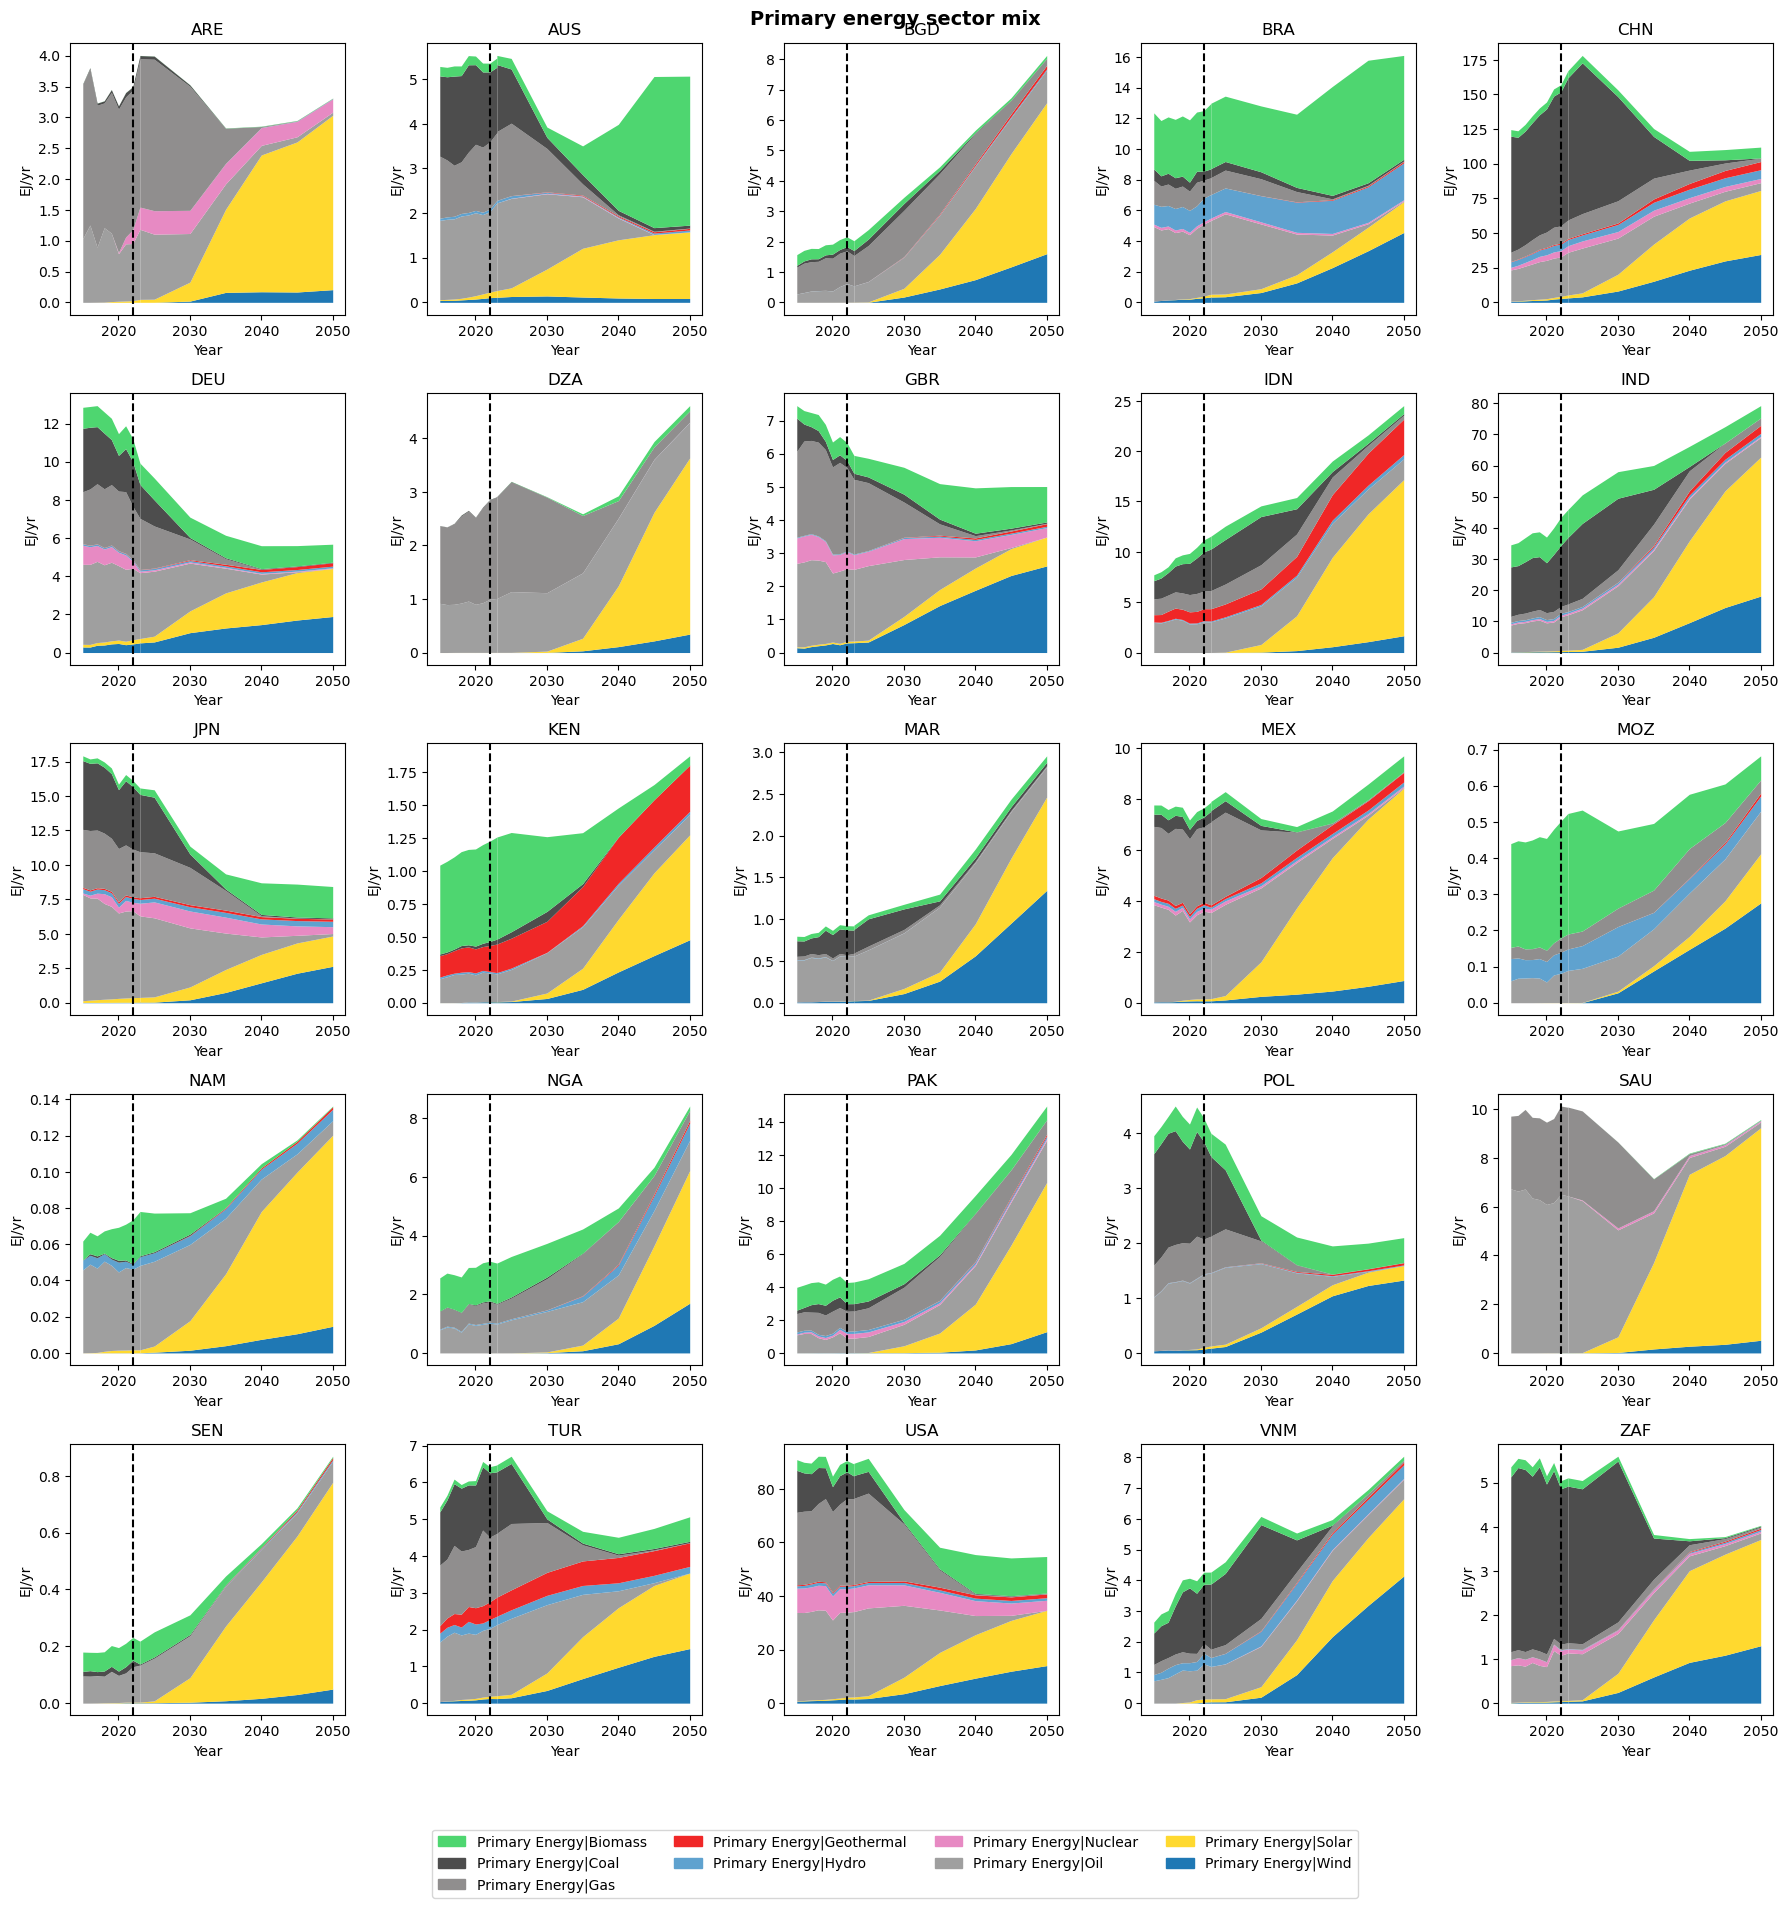

In [63]:
year_proj = [2023,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=primary_mix_var,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=primary_mix_var,
        year=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    ).plot.stack(ax=ax)

    ax.axvline(x=2022, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Primary energy sector mix',fontsize=14,fontweight='bold')
f.legend(legend_key,[l.get_label() for l in legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()
Path(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/primary_energy').mkdir(parents=True,exist_ok=True)
plt.savefig(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/primary_energy/fuel_mix.png',dpi=300)
     